# 01 - Análisis exploratorio (EDA)

Limpieza inicial, análisis univariado, bivariado, multivariado, distribución de fraude vs. monto y score, faltantes y correlaciones.

In [83]:
#Imports y configuración
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

from src.data import load_raw
from src import utils
from src.utils import PALETA, PALETA_CLASES

utils.set_style()
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [29]:
#Lectura del dataset
df = pd.read_csv(DATA_PATH, parse_dates=["fecha"])
df

,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,4845.0,141.0,1,N,Y,2020-03-14 11:46:13,40.89,23,0
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,2856.0,18.0,1,Y,N,2020-03-23 14:17:13,18.98,71,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,4,0.7728,34031.44,3.0,0.341379,18.0,BR,18,cat_039c51f,0.685681,2475.0,39.0,1,N,N,2020-04-11 17:25:30,5.47,37,0
149996,4,0.7569,81957.82,50.0,1.492911,5.0,BR,4,cat_fd8d8c5,0.669857,1073.0,672.0,1,NaN,Y,2020-03-22 08:46:51,2.53,8,0
149997,4,0.7012,77840.16,34.0,0.179331,3.0,BR,32,cat_ecc6934,0.315430,2497.0,219.0,1,NaN,Y,2020-04-09 11:35:40,6.28,57,0
149998,2,0.7206,31001.65,50.0,0.000000,50.0,UY,31,cat_851cfbb,0.813346,3952.0,84.0,1,NaN,N,2020-04-19 17:48:17,40.52,0,0


In [106]:
# Resumen por columna: tipo, nulos y cardinalidad
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(1),
    "unicos": df.nunique(),
}).sort_values("%_nulos", ascending=False)

print("Filas duplicadas:", df.duplicated().sum())
resumen

Filas duplicadas: 0


,tipo,nulos,%_nulos,unicos
o,object,108857,72.6,2
c,float64,12984,8.7,135090
b,float64,12984,8.7,7672
d,float64,365,0.2,51
m,float64,365,0.2,1793
g,object,194,0.1,51
a,int64,0,0.0,4
fraude,int64,0,0.0,2
score,int64,0,0.0,101
monto,float64,0,0.0,17831


*Hallazgos estructurales*

El dataset tiene 150.000 transacciones y 19 columnas. Las variables están anonimizadas con letras (`a`–`p`), más `fecha`, `monto`, `score` y el target `fraude` (1 = fraude, 0 = legítima).

- No hay registros duplicados
- **Valores faltantes:** la columna `o` tiene un 73% de nulos; `b` y `c` un ~9%; el resto son mínimos.
- **Tipos de variable:** conviven binarias (`n`, `o`, `p`), categóricas (`a`, `g` = país, `j` = categoría con 8.324 valores) y continuas (`b`, `c`, `e`, `monto`, etc.).
- La columna `k` tiene un valor distinto por fila (150.000 únicos). 

## Análisis Univariado

Conteo de clases:
fraude
0    142500
1      7500
Name: count, dtype: int64

Tasa de fraude: 5.00%


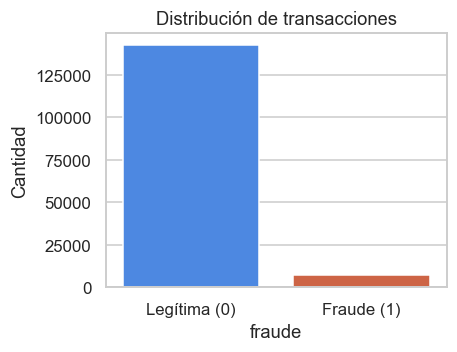

In [85]:
# Distribución del target
conteo = df["fraude"].value_counts()
tasa = df["fraude"].mean()
print("Conteo de clases:")
print(conteo)
print(f"\nTasa de fraude: {tasa:.2%}")

fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index, legend=False, ax=ax, palette=PALETA_CLASES)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Legítima (0)", "Fraude (1)"])
ax.set_ylabel("Cantidad")
ax.set_title("Distribución de transacciones")
plt.show()

De 150.000 transacciones, 7.500 son fraude: una **tasa del 5%**.
Es un desbalance moderado, por lo cual el *accuracy* no sirve como métrica (predecir "todo legítimo" acierta 95%).
Es necesario usar métricas sensibles a la clase rara (precision, recall, PR-AUC).

In [86]:
# Columnas de trabajo 
NUM_COLS = ["b", "c", "d", "e", "f", "h", "k", "l", "m", "monto", "score"]
CAT_COLS = ["a", "n", "o", "p", "g"]

### Variables numéricas

In [87]:
df[NUM_COLS].describe()

,b,c,d,e,f,h,k,l,m,monto,score
count,137016.000000,1.370160e+05,149635.000000,150000.000000,149989.000000,150000.000000,150000.000000,149989.000000,149635.000000,150000.000000,150000.000000
mean,0.728115,2.604451e+05,21.677669,0.220641,51.169352,14.193513,0.497532,2305.409403,299.969579,43.523134,48.066240
std,0.132943,8.464361e+05,20.062146,2.434995,709.472904,14.161216,0.288348,1712.379601,321.075806,91.557888,28.995122
min,0.000000,1.600000e-01,0.000000,0.000000,-5.000000,0.000000,0.000004,0.000000,0.000000,0.020000,0.000000
25%,0.678400,9.679915e+03,2.000000,0.000000,1.000000,3.000000,0.246819,910.000000,42.000000,9.380000,23.000000
50%,0.755500,4.371165e+04,14.000000,0.104875,8.000000,9.000000,0.495990,1937.000000,193.000000,20.610000,48.000000
75%,0.806500,1.454436e+05,50.000000,0.282938,33.000000,21.000000,0.746508,3445.000000,459.000000,40.692500,73.000000
max,1.000000,1.387874e+07,50.000000,833.333333,145274.000000,58.000000,0.999995,7544.000000,2225.000000,3696.350000,100.000000


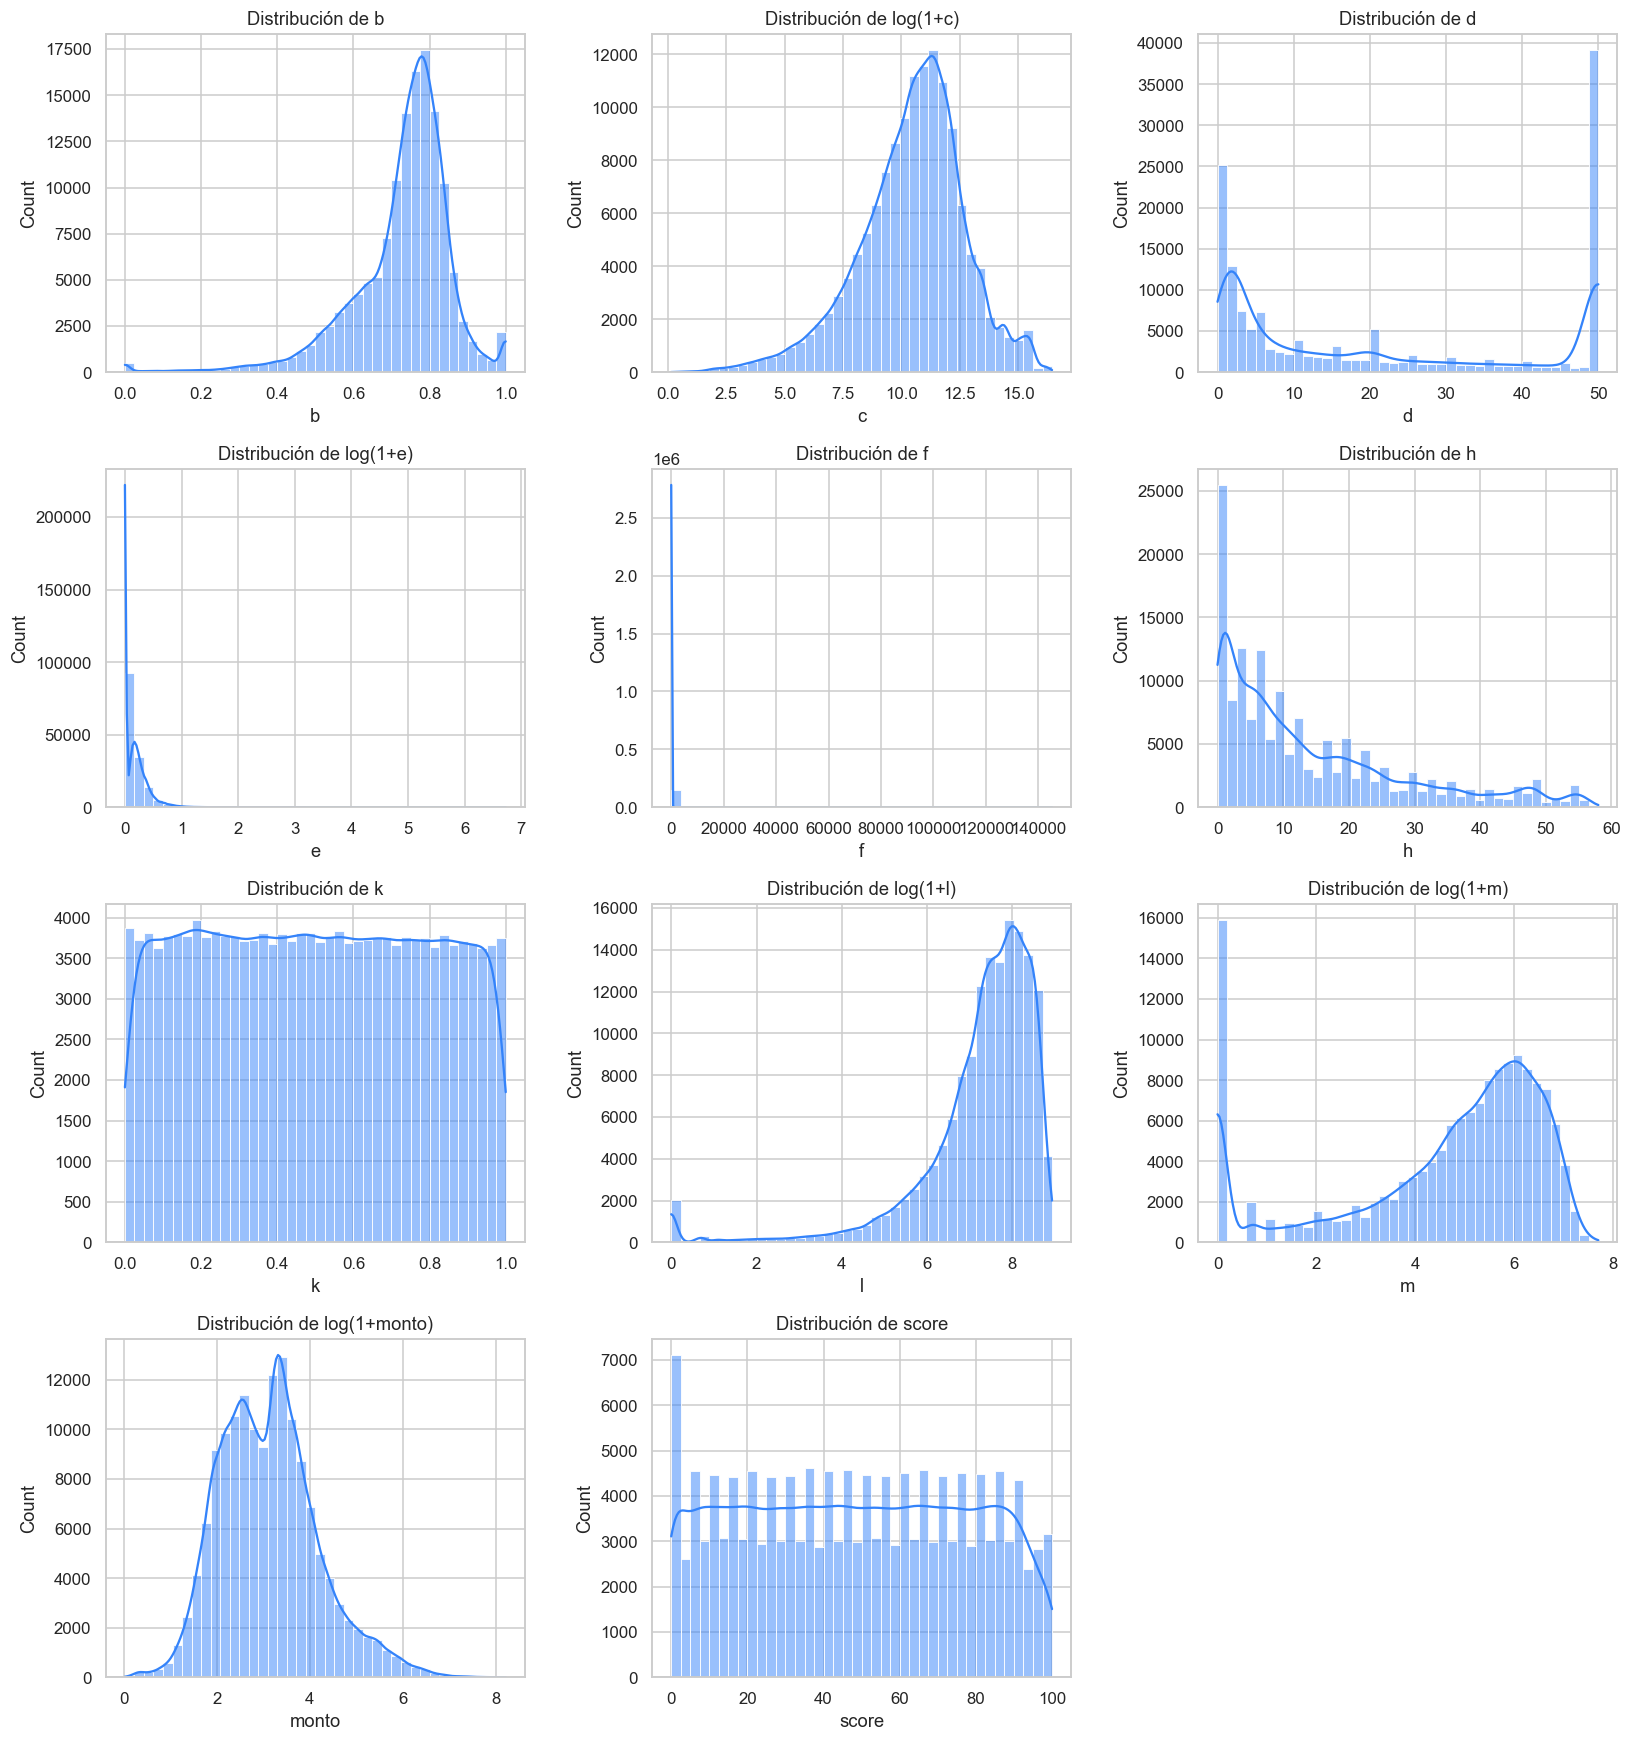

In [96]:
SESGADAS = {"c", "e", "l", "m", "monto"}  # se graficaran en log

fig, axes = utils.grid_axes(len(NUM_COLS), n_cols=3)

for ax, col in zip(axes, NUM_COLS):
    serie = np.log1p(df[col]) if col in SESGADAS else df[col]
    etiqueta = f"log(1+{col})" if col in SESGADAS else col
    sns.histplot(serie.dropna(), kde=True, bins=40, ax=ax, color=PALETA["principal"])
    ax.set_title(f"Distribución de {etiqueta}")
plt.tight_layout()
plt.show()

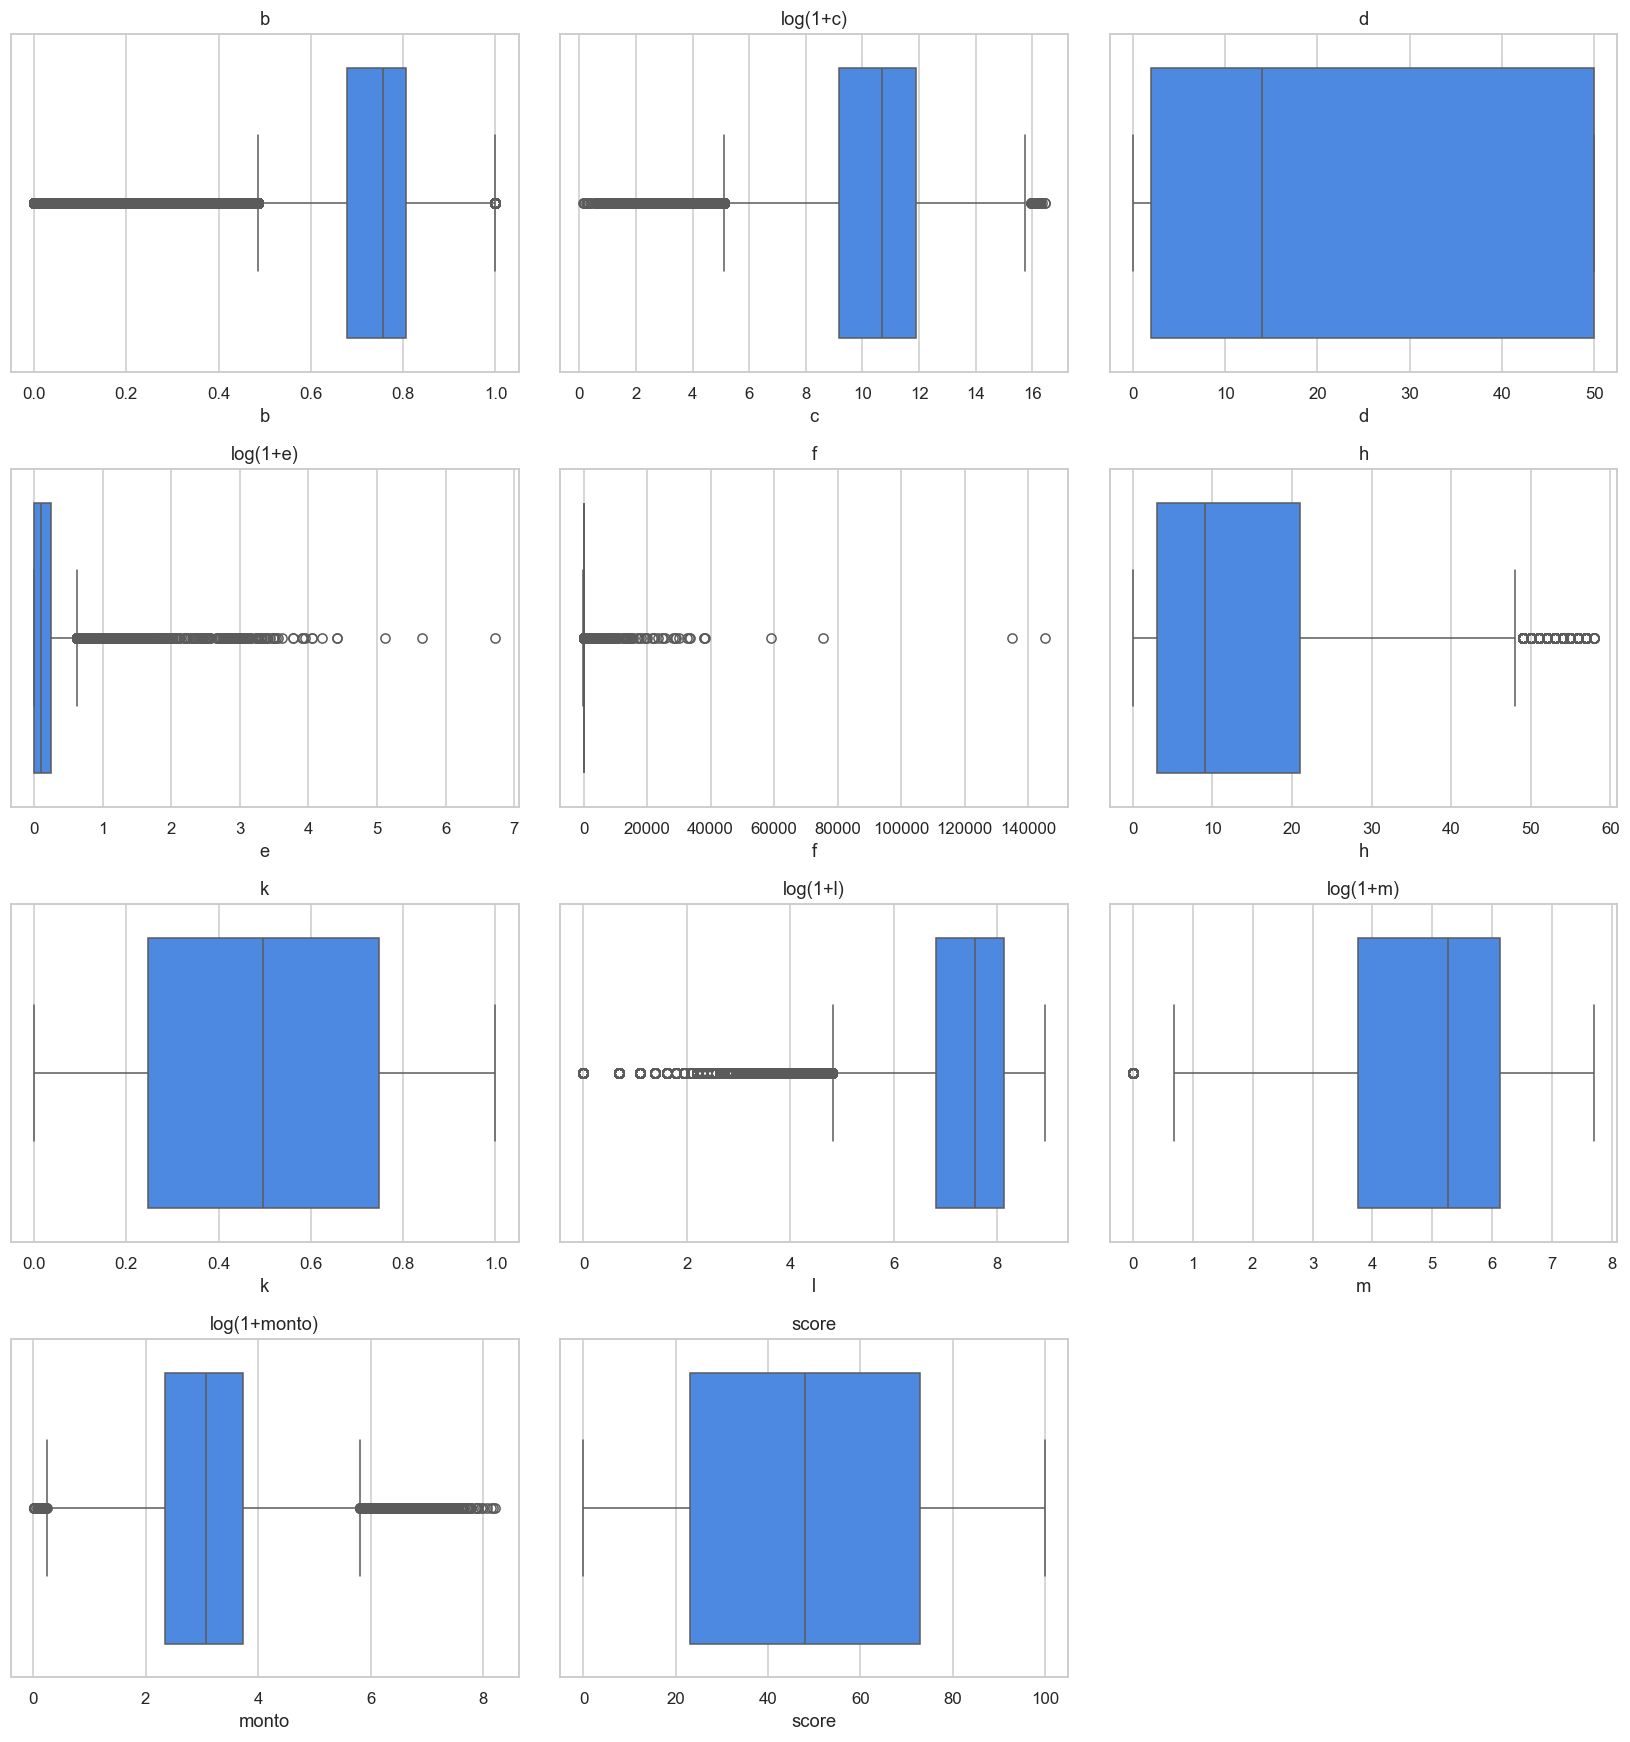

In [97]:
# Boxplots para detectar outliers

fig, axes = utils.grid_axes(len(NUM_COLS), n_cols=3)
for ax, col in zip(axes, NUM_COLS):
    serie = np.log1p(df[col]) if col in SESGADAS else df[col]
    etiqueta = f"log(1+{col})" if col in SESGADAS else col
    sns.boxplot(x=serie, ax=ax, color=PALETA["principal"])
    ax.set_title(etiqueta)
plt.tight_layout()
plt.show()

- **`k`** es uniforme en [0, 1] y además tiene un valor único por fila.
  sin señal. Se descartará.
- **`d`** es bimodal con una acumulación fuerte en 50 (un *cap* artificial) y
  otra cerca de 0.
- **`e`** y **`f`** están casi totalmente concentradas en valores bajos, con
  outliers extremos y aislados (`f` además tiene negativos). Aportan poca
  variación; habrá que tratar los outliers con cuidado.
- **`c`, `l`, `m`, `monto`** son muy sesgadas: en escala log se normalizan
  (varias con un pico en 0, es decir "cero-infladas").
- **`score`** se reparte de forma pareja en 0–100, con un pico en 0.

- `f` tiene valores negativos (mín. -5) y outliers extremos (máx. ~145k).
- `c` es un importe muy sesgado (hasta ~13,8 M)
- `d` parece recortada en 50 (máximo y percentil 75 = 50).
- `monto` confirma su sesgo a la derecha (mediana 20,6; máx. 3.696).

### Variables categóricas

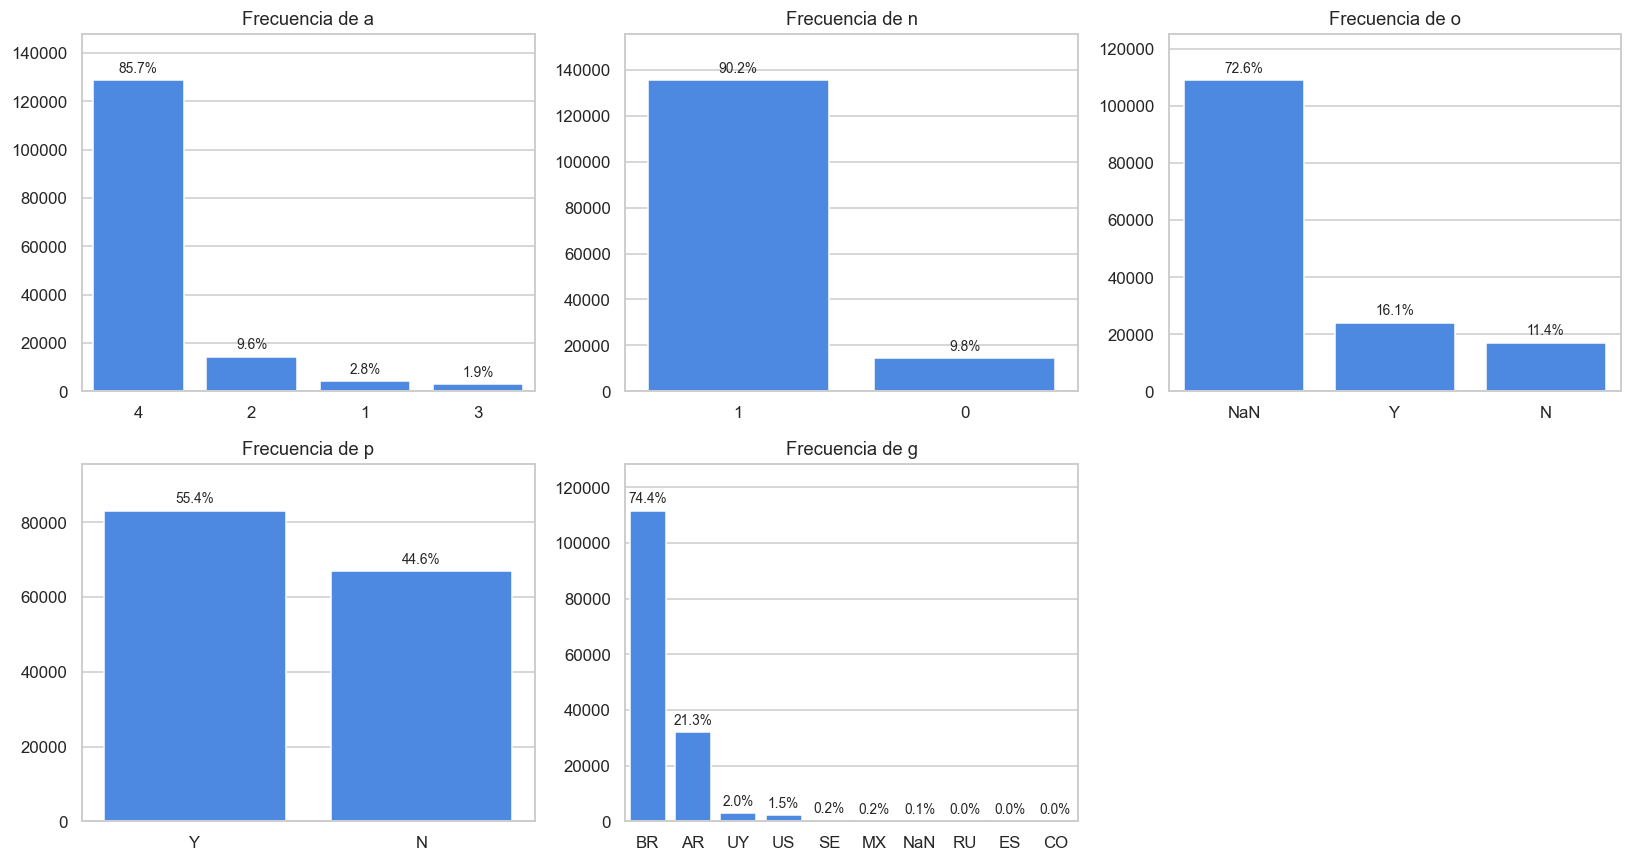

In [98]:
fig, axes = utils.grid_axes(len(CAT_COLS), n_cols=3)
for ax, col in zip(axes, CAT_COLS):
    vc = df[col].value_counts(dropna=False)
    if col == "g":
        vc = vc.head(10)
    etiquetas = [str(x) if pd.notna(x) else "NaN" for x in vc.index]
    sns.barplot(x=etiquetas, y=vc.values, ax=ax, color=PALETA["principal"])
    ax.set_title(f"Frecuencia de {col}")

    # Porcentaje encima de cada barra
    porcentajes = [f"{v / len(df) * 100:.1f}%" for v in vc.values]
    ax.bar_label(ax.containers[0], labels=porcentajes, padding=3, fontsize=9)
    ax.margins(y=0.15)   
plt.tight_layout()
plt.show()

- **`a`:** dominada por un valor (86% en la categoría 4).
- **`g`:** dominan Brasil y Argentina, los demás paises tienen pocos registros por lo que es prudente agruparlos en una categoría "otros".
- **`n`:** binaria, 90% en la clase 1. Está desbalanceada. 
- **`o`:** 73% vacía; el vacío se tratará como categoría propia.
- **`p`:** binaria y balanceada (55/45).

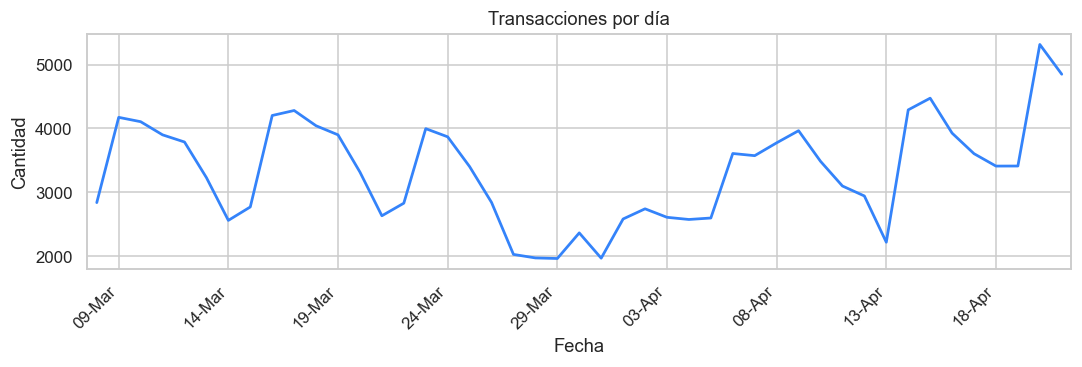

In [57]:
por_dia = df.set_index("fecha").resample("D").size()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(por_dia.index, por_dia.values, color=PALETA["principal"], lw=1.8)
ax.set_title("Transacciones por día")
ax.set_ylabel("Cantidad")
ax.set_xlabel("Fecha")

# Una marca cada 5 días, con formato "día-mes"
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
fig.autofmt_xdate(rotation=45)
ax.margins(x=0.01)

plt.tight_layout()
plt.show()

En la distribución temporal los datos cubren del 8 de marzo al 21 de abril de 2020 (~45 días). El volumen diario oscila entre ~2.000 y ~5.000 transacciones, con un valle marcado a fin
de mes. Este rango temporal es la base del split *out-of-time* que debe usarse para evaluar el modelo simulando producción.

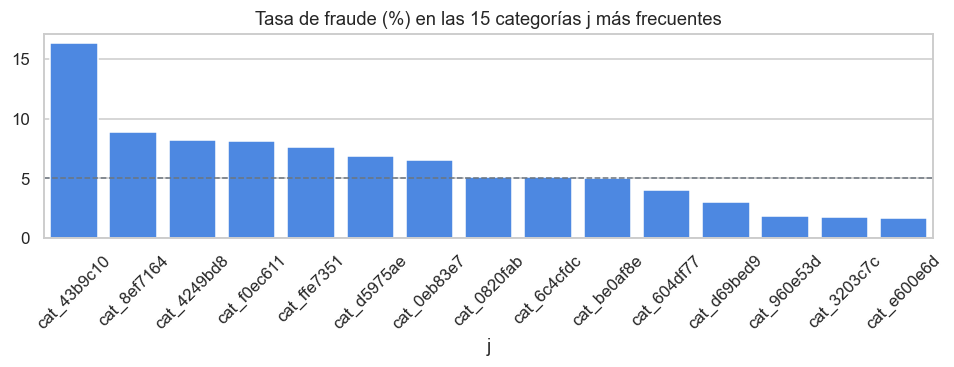

In [94]:
# Tasa de fraude en las 15 categorías de 'j' con más transacciones
top_j = df["j"].value_counts().head(15).index
sub = df[df["j"].isin(top_j)]
tasa_j = (sub.groupby("j")["fraude"].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.barplot(x=tasa_j.index, y=tasa_j.values, ax=ax, color=PALETA["principal"])
ax.axhline(df["fraude"].mean() * 100, color=PALETA["neutro"], ls="--", lw=1)
ax.set_title("Tasa de fraude (%) en las 15 categorías j más frecuentes")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

- J tiene 8.324 categorías, muy repartidas (mediana de 4 filas/categoría; 60% con ≤5).
- Entre las categorías con más volumen, la tasa de fraude va de 0% a ~25%.
- No es viable one-hot (8.324 columnas) ni graficarla completa. Requerirá un
  encoding especial.

## Análisis Bivariado

### Variables numéricas

In [92]:
comparacion = df.groupby("fraude")[NUM_COLS].mean().T
comparacion.columns = ["legitima", "fraude"]
comparacion["ratio"] = comparacion["fraude"] / comparacion["legitima"]
comparacion.sort_values("ratio", ascending=False)

,legitima,fraude,ratio
monto,41.973326,72.969483,1.738473
c,254082.178440,384770.684747,1.514355
score,46.917207,69.897867,1.489813
b,0.726945,0.750986,1.033071
k,0.497374,0.500543,1.006371
e,0.221904,0.196641,0.886153
h,14.306779,12.041467,0.841662
d,22.035508,14.868425,0.674748
l,2351.383138,1431.975867,0.608993
m,306.846923,169.102128,0.551096


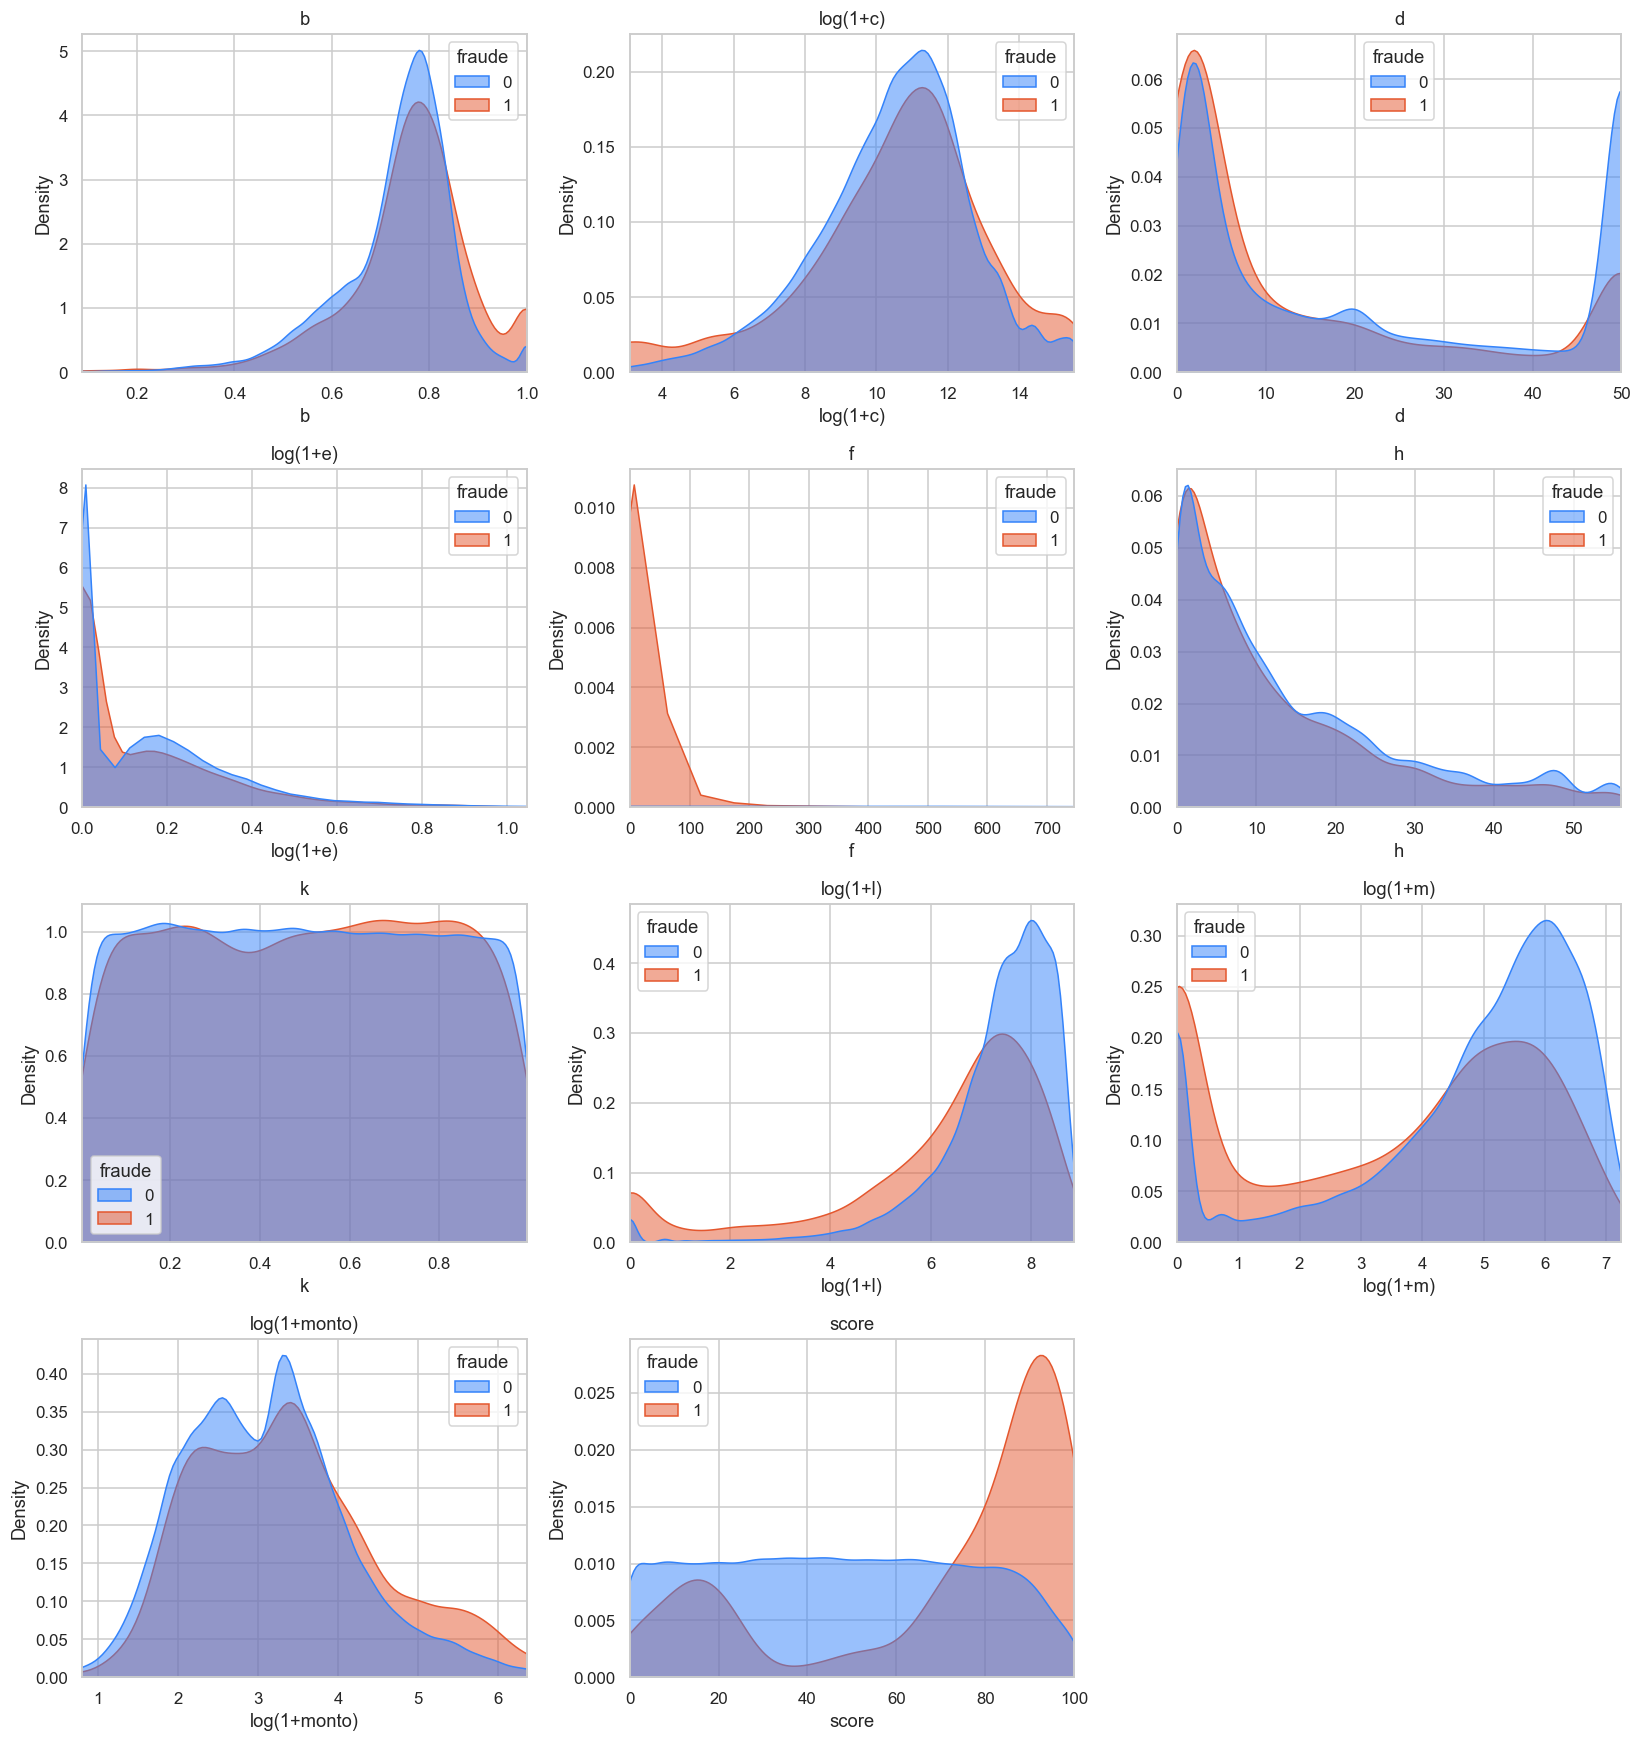

In [99]:
fig, axes = utils.grid_axes(len(NUM_COLS), n_cols=3)
for ax, col in zip(axes, NUM_COLS):
    serie = np.log1p(df[col]) if col in SESGADAS else df[col]
    etiqueta = f"log(1+{col})" if col in SESGADAS else col
    tmp = pd.DataFrame({etiqueta: serie, "fraude": df["fraude"]})
    sns.kdeplot(data=tmp, x=etiqueta, hue="fraude", fill=True,
                common_norm=False, palette=PALETA_CLASES, alpha=0.5, ax=ax)
    ax.set_title(etiqueta)
    # recorta el eje para que los outliers extremos no aplasten la curva
    lo, hi = np.nanpercentile(serie, [0.5, 99.5])
    ax.set_xlim(lo, hi)
plt.tight_layout()
plt.show()

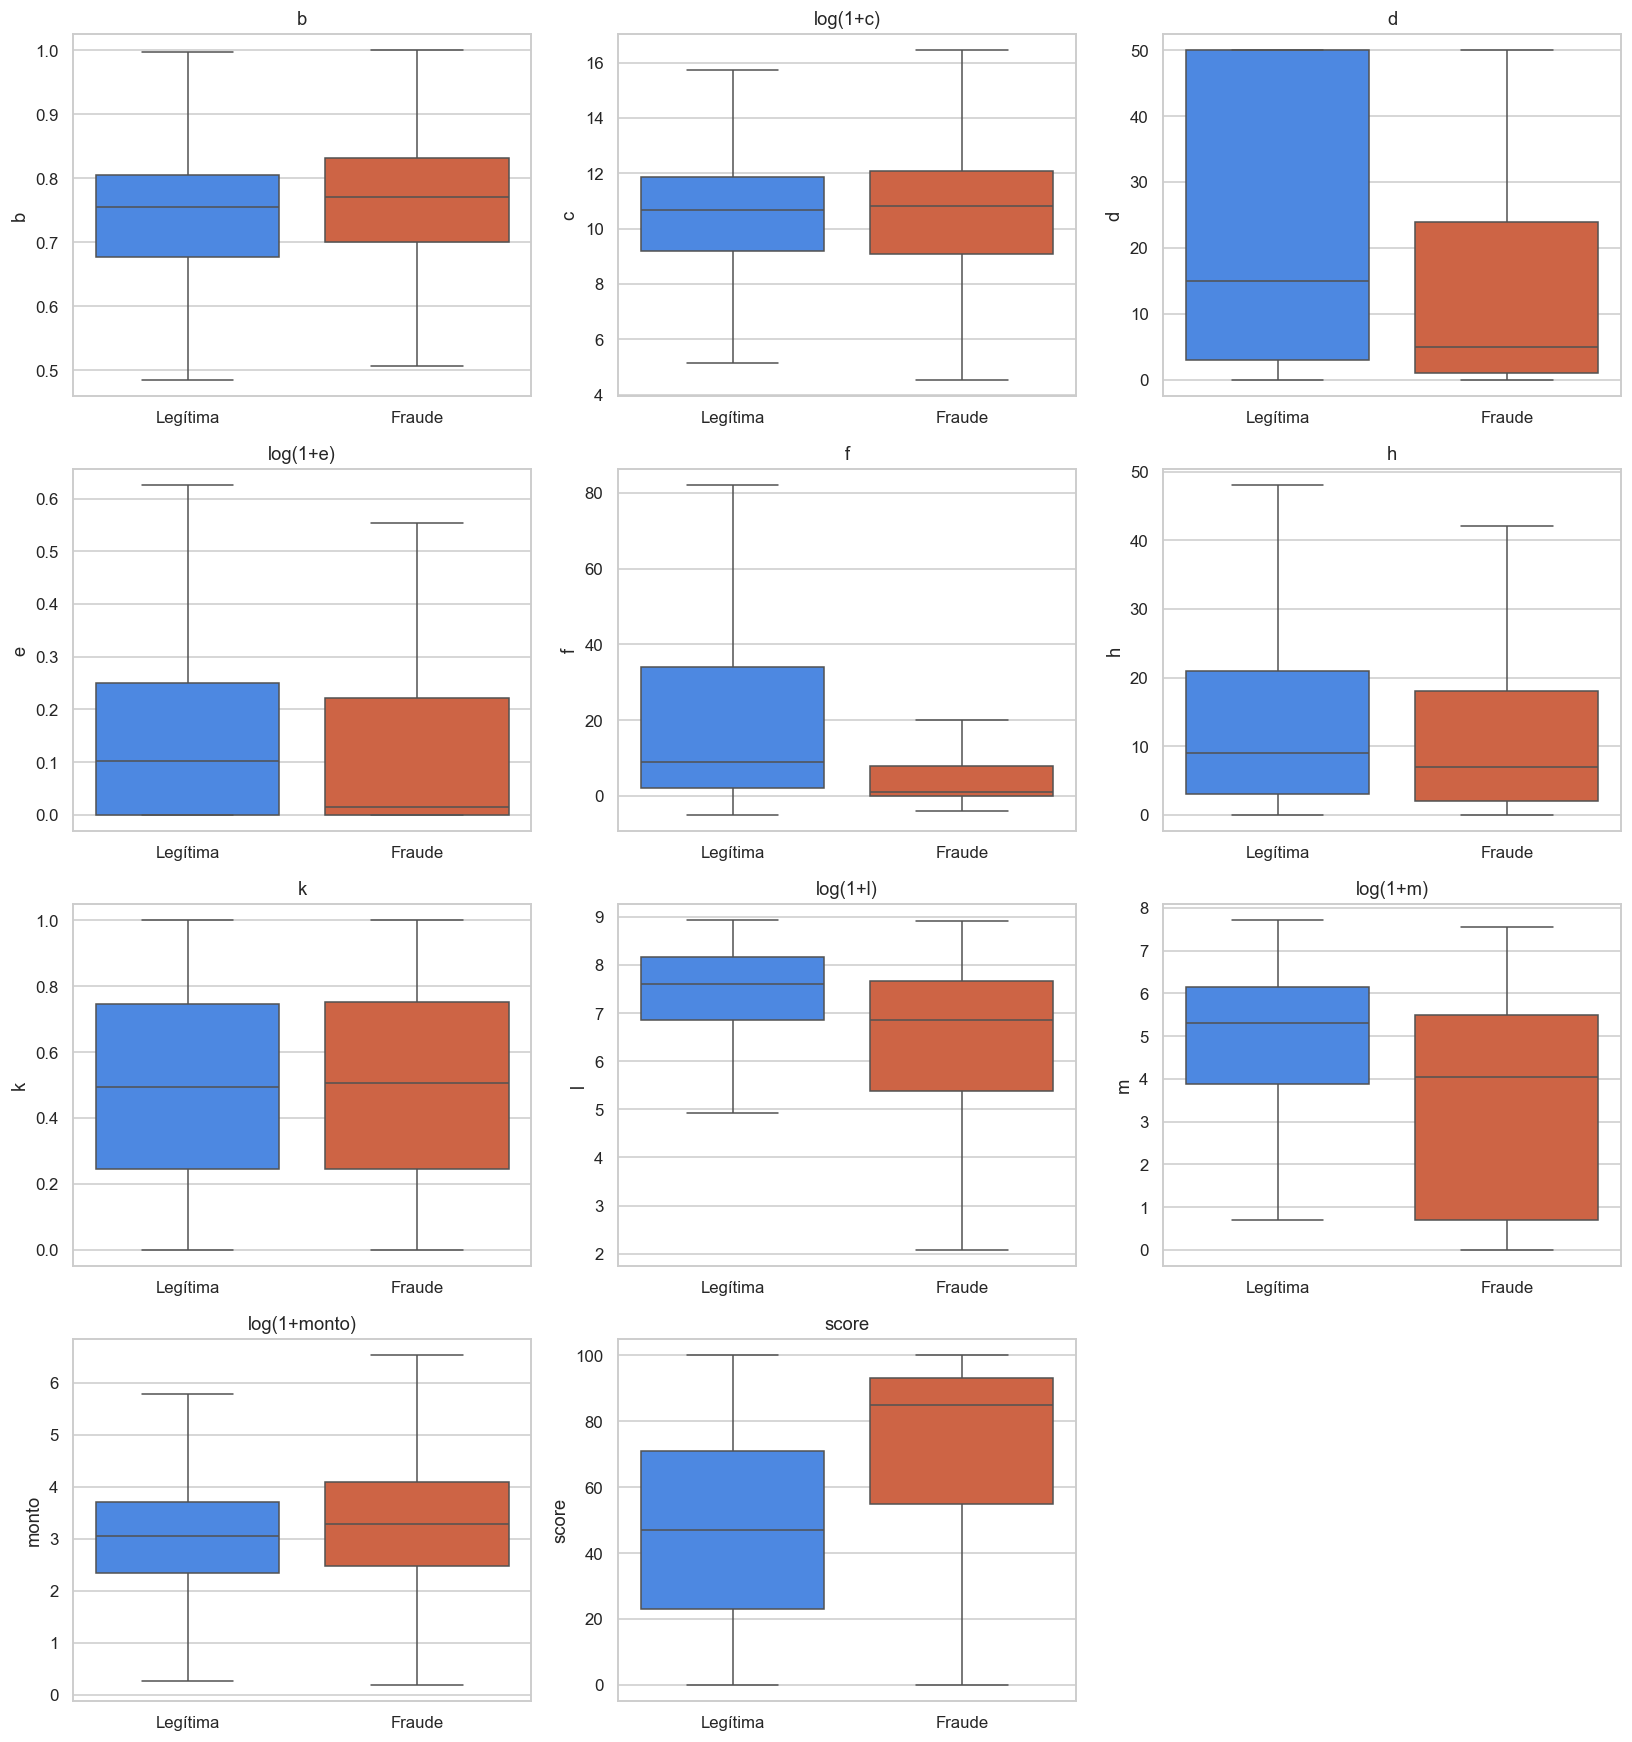

In [100]:
fig, axes = utils.grid_axes(len(NUM_COLS), n_cols=3)
for ax, col in zip(axes, NUM_COLS):
    y = np.log1p(df[col]) if col in SESGADAS else df[col]
    etiqueta = f"log(1+{col})" if col in SESGADAS else col
    sns.boxplot(x=df["fraude"], y=y, hue=df["fraude"], palette=PALETA_CLASES,
                legend=False, showfliers=False, ax=ax)   # sin outliers, para ver mejor las cajas
    ax.set_title(etiqueta)
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Legítima", "Fraude"])
plt.tight_layout()
plt.show()

Cruzando la tabla de ratios con las distribuciones por clase:

- **Señal fuerte:** `score` (fraude en valores altos; mejor predictor),
  `f`, `m`, `l`, `d` (fraude en valores bajos).
- **Señal por la cola:** `monto` — el grueso se superpone, pero el fraude
  domina en los montos altos.
- **Sin señal:** `b`, `e` y `k` (curvas encimadas) → se confirma descartar `k`.
- **`c`:** ratio de medias alto (1.51) pero distribuciones
  superpuestas. La separación aparente viene de outliers extremos, no de una
  diferencia real. 

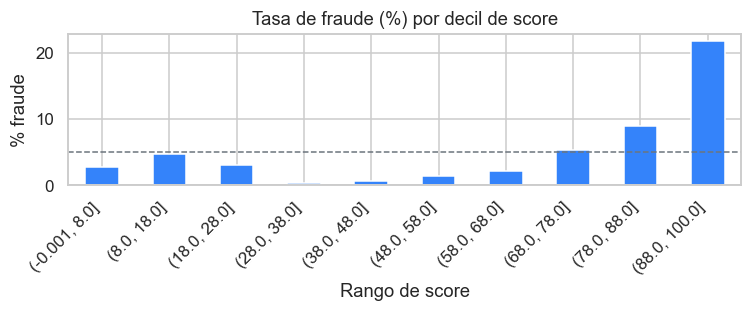

In [101]:
# Fraude según el nivel de score
score_bin = pd.qcut(df["score"], 10, duplicates="drop")
tasa_por_score = df["fraude"].groupby(score_bin, observed=True).mean() * 100

fig, ax = plt.subplots(figsize=(7, 3))
tasa_por_score.plot(kind="bar", ax=ax, color=PALETA["principal"])
ax.axhline(df["fraude"].mean() * 100, color=PALETA["neutro"], ls="--", lw=1)  # tasa global
ax.set_title("Tasa de fraude (%) por decil de score")
ax.set_ylabel("% fraude")
ax.set_xlabel("Rango de score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Variables categóricas

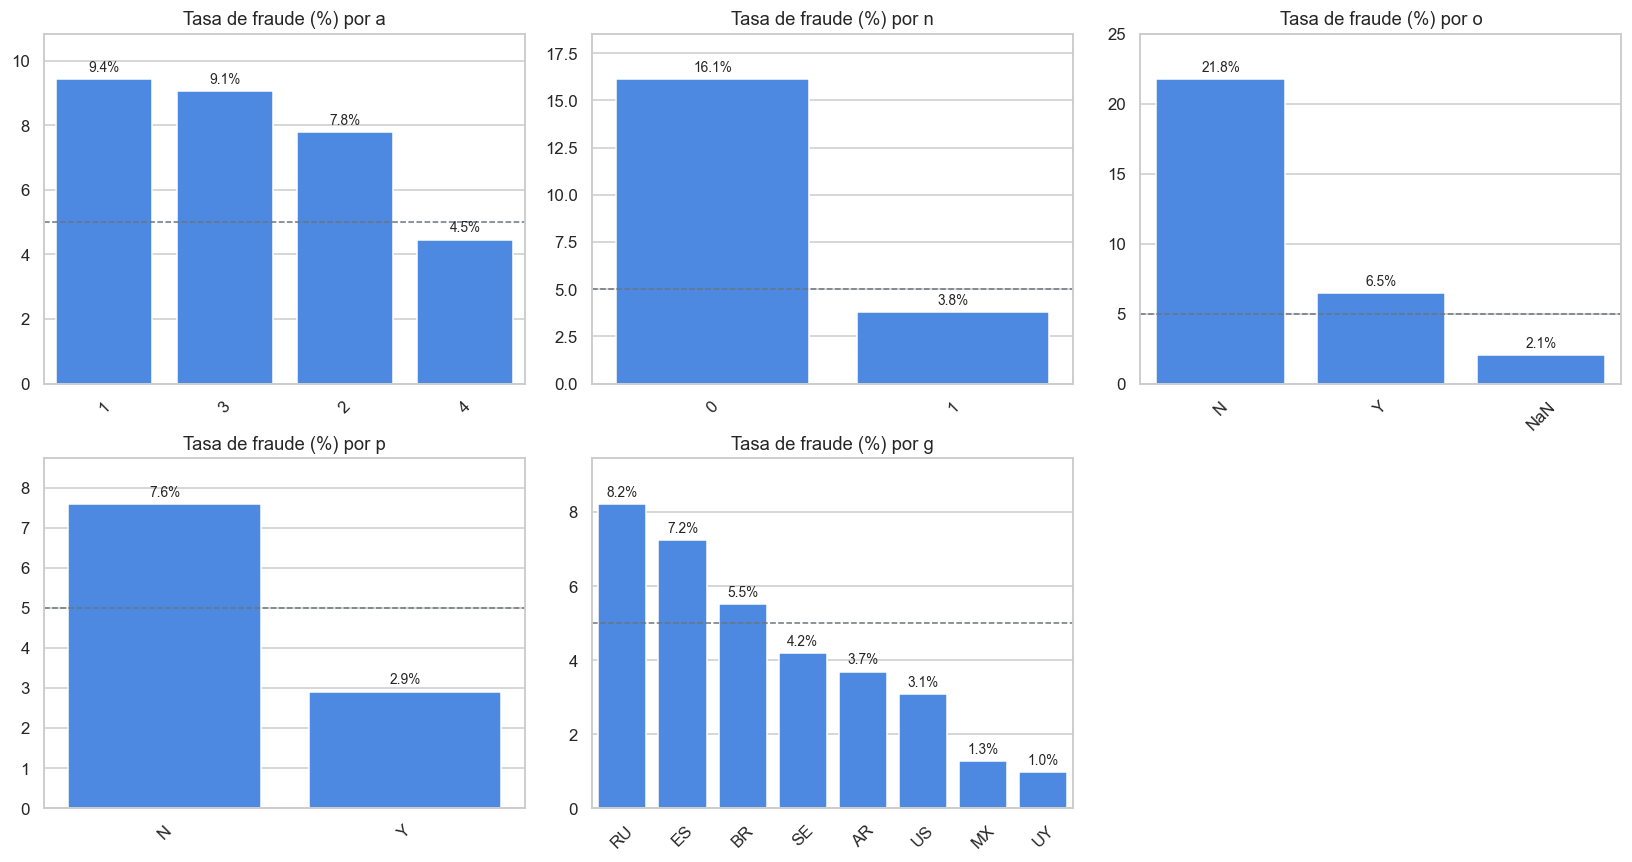

In [104]:
tasa_global = df["fraude"].mean() * 100

fig, axes = utils.grid_axes(len(CAT_COLS), n_cols=3)
for ax, col in zip(axes, CAT_COLS):
    serie = df[col].fillna("NaN")
    tasa = df.assign(_cat=serie).groupby("_cat")["fraude"].mean().mul(100)
    if col == "g":                       # solo top 8 países por volumen (los demás, pocos datos)
        top = df["g"].value_counts().head(8).index.astype(str)
        tasa = tasa[tasa.index.isin(top)]
    tasa = tasa.sort_values(ascending=False)
    etiquetas = [str(x) for x in tasa.index]
    sns.barplot(x=etiquetas, y=tasa.values, ax=ax, color=PALETA["principal"])
    ax.axhline(tasa_global, color=PALETA["neutro"], ls="--", lw=1)   # tasa global
    ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, fontsize=9)
    ax.margins(y=0.15)
    ax.set_title(f"Tasa de fraude (%) por {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Tasa de fraude por categoría vs. tasa global (5%):

- **`o`:** valor N ~22%, Y ~6%, vacío ~2%. La **ausencia es informativa**
  (menos fraude) → se conserva como categoría propia.
- **`n`:** valor 0 ~16% vs. valor 1 ~4%. Muy discriminante.
- **`p`:** N (~7,6%) casi duplica a Y (~2,9%).
- **`a`:** la categoría dominante (4) tiene menos fraude (~4,5%); las raras,
  más (~8–9%).
- **`g` (país):** cerca de la media; las tasas extremas son de países con
  muy pocos registros (poco confiables).

## Análisis Multivariado

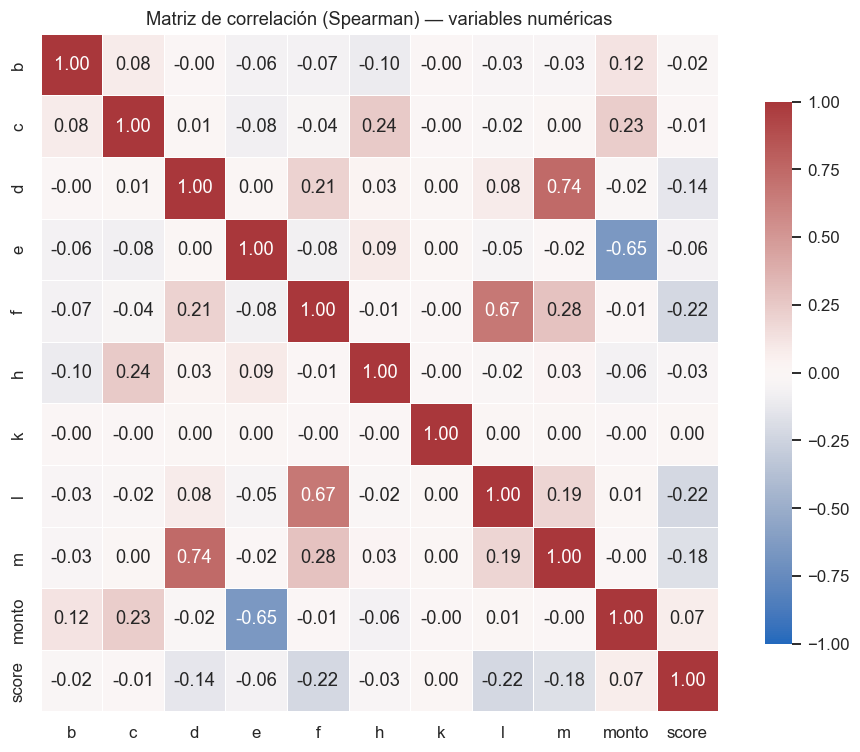

In [105]:
corr = df[NUM_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlación (Spearman) — variables numéricas")
plt.tight_layout()
plt.show()

Se usa la correlación de Spearman por la presencia de sesgo y outliers (más robusta que Pearson).

- **Pares redundantes:** `d`–`m` (0.74), `f`–`l` (0.67), `e`–`monto` (−0.65).
  Información parcialmente duplicada.
- **`k` no se correlaciona con ninguna variable** (fila/columna en 0):
  tercera confirmación de que es ruido → se descarta.

## Conclusiones del EDA

### Resumen del dataset
150.000 transacciones, 19 columnas, sin duplicados. Variables anonimizadas
(`a`–`p`) más `fecha`, `monto`, `score` y el target `fraude`. Tasa de fraude
del **5%** (desbalance moderado).

### Predictores identificados (señal frente al fraude)
- **`score`** es el predictor más fuerte: a mayor score, mayor fraude (en el
  decil superior, ~22% vs. 5% general). Es, muy probablemente, el sistema de
  fraude actual → **baseline a superar**.
- Señal directa por la cola: **`monto`** (el fraude domina en montos altos,
  clave por la economía del reto).
- Señal inversa (más bajas en fraude): **`f`, `m`, `l`, `d`**.
- Categóricas discriminantes: **`o`** (el valor N ~22%, el vacío ~2% → la
  ausencia informa), **`n`** (valor 0 ~16%), **`p`** (N duplica a Y).

### Variables sin valor
- **`k`:** ruido. Uniforme en [0,1], un valor único por fila, sin correlación
  con nada ni con el target. **Se descarta.**
- **`b`, `e`:** sin señal frente al fraude (curvas encimadas).
- **`c`:** su ratio de medias alto es un artefacto de outliers extremos; las
  distribuciones por clase se superponen (señal débil).

### Decisiones para preprocesamiento y features (notebook 02)
- **Descartar `k`.**
- **Transformación log** `log(1+x)` para las sesgadas no negativas:
  `c`, `l`, `m`, `monto`, `e`.
- **`f`:** tratar outliers y negativos (winsorizar o transformación que
  respete el signo); no admite `log1p` por sus valores negativos.
- **`o`:** imputar el vacío como categoría propia (es informativo).
- **`g` (país):** agrupar países de bajo volumen en "otros".
- **`j` (alta cardinalidad):** encoding especial (target/frequency encoding o
  categórica nativa de LightGBM), ajustado **solo en train** para evitar fugas.
- **Faltantes menores** (`b`, `c`, `d`, `m`, `f`, `l`): imputar, ajustando el
  imputador solo en train.
- **`d`:** tener presente el cap artificial en 50.

### Notas metodológicas
- **Split temporal (out-of-time):** entrenar con los primeros días
  (mar–abr 2020) y evaluar con los últimos, para simular producción.
- **Redundancias** (`d`–`m`, `f`–`l`, `e`–`monto`): no afectan a LightGBM,
  pero se consideran para interpretabilidad (SHAP) y un baseline lineal.
- **Métrica:** ganancia neta simulada (objetivo del reto) como principal, con
  PR-AUC como secundaria; usar pesos de clase por el desbalance.